In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
separators = [',', ';', '\t', '|']

for sep in separators:
    try:
        df = pd.read_csv('ALL_SPB_STOPS.csv', encoding='windows-1251', sep=sep)
        print(f"Успешно! Разделитель: '{sep}'")
        print(f"Размер: {df.shape}")
        break
    except Exception as e:
        print(f"Не подошел '{sep}': {e}")

df = df[['LATITUDE', 'LONGITUDE']].dropna()
df

Не подошел ',': Error tokenizing data. C error: Expected 1 fields in line 77, saw 7

Успешно! Разделитель: ';'
Размер: (7154, 4)


,LATITUDE,LONGITUDE
0,59.841604,30.253984
1,59.842042,30.250084
2,59.851683,30.268385
3,59.849710,30.268348
4,59.867292,30.261133
...,...,...
7149,59.950695,30.266132
7150,59.945698,30.271969
7151,59.936026,30.309259
7152,60.031439,30.392572


In [38]:
mask = df['ID_STOP'].apply(lambda x: str(x)[:3] == '100' and len(str(x)) >= 6)
df = df[mask]
df

,ID_STOP,STOP_NAME,LATITUDE,LONGITUDE
0,100101,Пр.Ветеранов-1,59.841604,30.253984
1,100102,Пр.Ветеранов-2,59.842042,30.250084
2,100103,Ленинский пр.-1,59.851683,30.268385
3,100104,Ленинский пр.-2,59.849710,30.268348
4,100105,Автово,59.867292,30.261133
...,...,...,...,...
70,100513,Чкаловская,59.960987,30.292046
71,100514,Крестовский остров,59.971792,30.259414
72,100515,Старая Деревня,59.989538,30.255218
73,100516,Комендантский пр.,60.007810,30.259476


In [57]:
from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV
kmeans = KMeans()
grid = {'n_clusters': range(1, 8)}

gridsearchCV = GridSearchCV(kmeans, grid, cv = 3, )

579.3112199916227
263.78162127621096
202.97536482419176
157.01038018630607
130.1901009190569
109.39293934173108
91.16565450893027
79.14085470955996
68.15557952514115
60.18282806976528
53.4618472040823
47.82032477967492
41.03589404777118
37.22603773064976
33.81905979150138


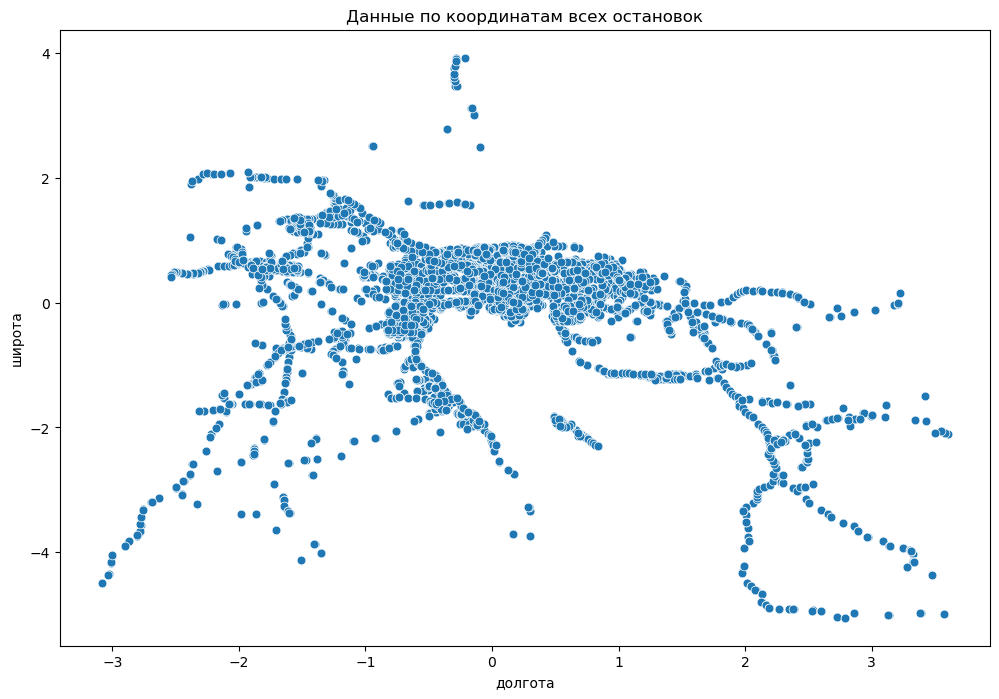

In [60]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X = df[['LATITUDE', 'LONGITUDE']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
fig = plt.figure(figsize= (12, 8))
sns.scatterplot(x = X_scaled[: ,0], y = X_scaled[: ,1], s = 40)
plt.title('Данные по координатам всех остановок')
plt.xlabel('долгота')
plt.ylabel('широта')

css = []
for i in range(1, 16):
    kmeans = KMeans(n_clusters= i, n_init= 10, random_state= 42)
    kmeans.fit(X)
    print(kmeans.inertia_)
    css.append(kmeans.inertia_)

ValueError: `legend` must be 'auto', 'brief', 'full', or a boolean.

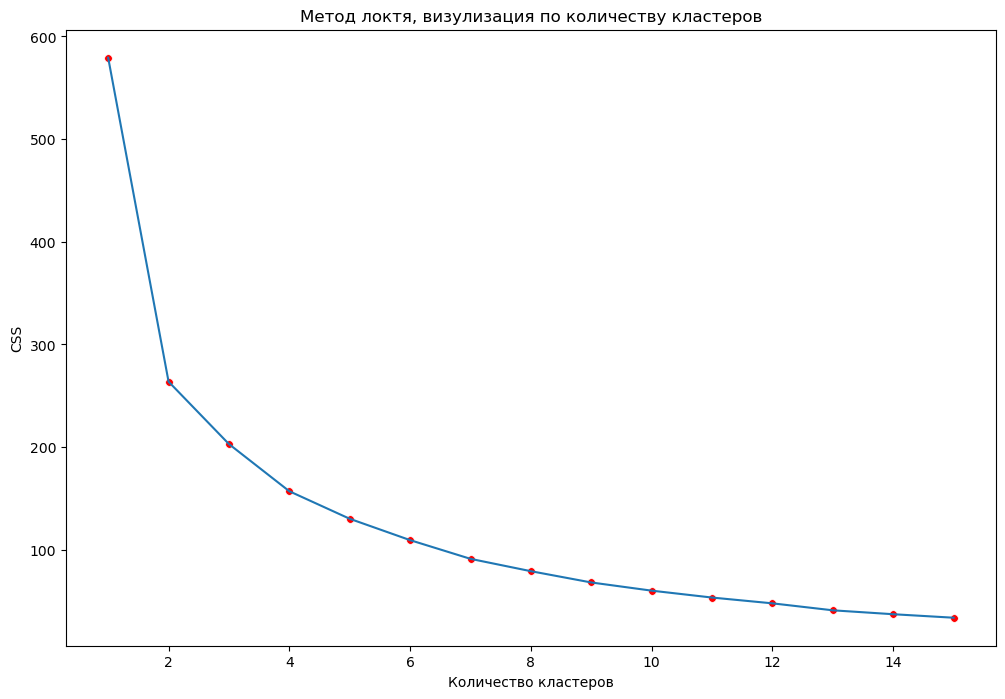

In [62]:
fig = plt.figure(figsize= (12, 8))
plt.plot(np.arange(1, 16), css)
plt.title('Метод локтя, визулизация по количеству кластеров')
plt.xlabel('Количество кластеров')
plt.ylabel('CSS')
sns.scatterplot(x = np.arange(1, 16), y = css, color = 'red', s = 30, legend= 'Значения CSS')



'''sns.scatterplot(x = X_scaled[: ,0], y = X_scaled[: ,1], s = 40)'''

# ПО ГРАФИКУ ЛОКТЯ ЯСНО, ЧТО ЧИСЛО K = 5 - САМОЕ ПОДХОДЯЩЕЕ ДЛЯ КЛАСТЕРИЗАЦИИ ОСТАНОВОК ПЕТЕРБУРГА

0.5606428120428036
0.39476036066921405
0.416316472582881
0.40784235369011906
0.4076733630916342
0.3863005438094144
0.4085645265661061
0.38589718512703564
0.3963030152790077
0.401143712928859
0.40869766323378615
0.4277053991773894
0.4339998869142867
0.4315609002993782


ValueError: `legend` must be 'auto', 'brief', 'full', or a boolean.

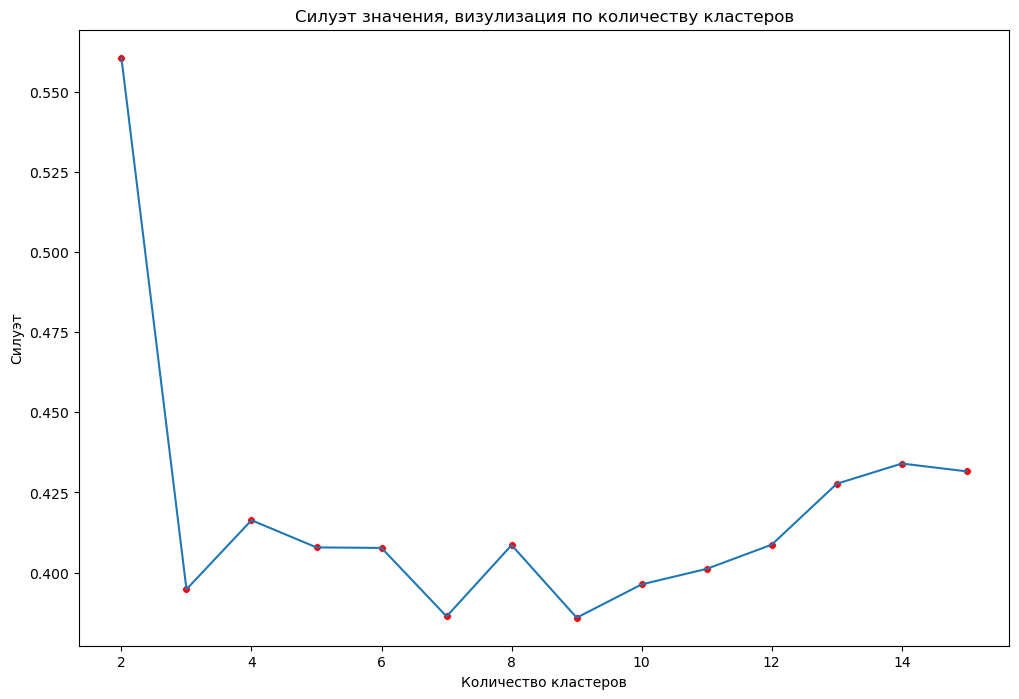

In [72]:
from sklearn.metrics import silhouette_score
silhouette_scores = []

for k in range(2, 16):
    kmeans = KMeans(n_clusters= k, n_init= 10, random_state= 42)
    kmeans.fit(X_scaled)
    labels_X_scaled = kmeans.labels_
    print(silhouette_score(X_scaled, labels_X_scaled))
    silhouette_scores.append(silhouette_score(X_scaled, labels_X_scaled))

fig = plt.figure(figsize= (12, 8))
plt.plot(np.arange(2, 16), silhouette_scores)
plt.title('Силуэт значения, визулизация по количеству кластеров')
plt.xlabel('Количество кластеров')
plt.ylabel('Силуэт')
sns.scatterplot(x = np.arange(2, 16), y = silhouette_scores, color = 'red', s = 30, legend= 'Значения Силуэтаээ')
plt.legend('Значения [-1, 1];стремление к 1 - идеальная кластеризация')

    